## Ridge and Lasso

In [1]:
## Ridge & Lasso 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import load_diabetes, fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
# ── DATA CREATION ──────────────────────────────────────────────────────────
# The Diabetes dataset has 10 features and 442 samples.
# We split 80% for training and 20% for testing.
# StandardScaler is applied so all features are on the same scale.

diabetes = load_diabetes()
print(diabetes)
X, y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit on train, transform train
X_test_s  = scaler.transform(X_test)       # only transform test (no fit)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Number of features: {X.shape[1]}')
print(f'Features: {feature_names}')

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10)), 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [3]:
# ── YOUR SOLUTION ───────────────────────────────────────────────────────────
# Fit Ridge regression for each alpha value and record test MSE and coef norm.
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

test_mse = []
coef_norms = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)

    ridge.fit(X_train_s, y_train)
    y_ridge_predict = ridge.predict(X_test_s)

    test_mse.append(mean_squared_error(y_test, y_ridge_predict))
    coef_norms.append(np.linalg.norm(ridge.coef_))

print(f"{'Alpha':>10}  {'Test MSE':>12}  {'Coef L2 Norm':>14}")
print('-' * 42)
for alpha, mse, norm in zip(alphas, test_mse, coef_norms):
    print(f"{alpha:>10.3f}  {mse:>12.3f}  {norm:>14.3f}")

     Alpha      Test MSE    Coef L2 Norm
------------------------------------------
     0.001      2900.182          71.615
     0.010      2900.075          71.484
     0.100      2899.055          70.214
     1.000      2892.015          60.909
    10.000      2875.779          43.028
   100.000      2858.224          34.283
  1000.000      3451.711          15.884


In [4]:
## Lasso
# ── DATA CREATION ──────────────────────────────────────────────────────────
# Using the same Diabetes dataset from Problem 1.
# X_train_s, X_test_s, y_train, y_test are already created above.

lasso_alphas = [0.001, 0.01, 0.1, 0.5, 1, 5, 10]

print('Lasso alpha values to test:', lasso_alphas)
print(f'Total features in dataset: {X_train_s.shape[1]}')
print('Note: We expect Lasso to select fewer features as alpha increases.')

Lasso alpha values to test: [0.001, 0.01, 0.1, 0.5, 1, 5, 10]
Total features in dataset: 10
Note: We expect Lasso to select fewer features as alpha increases.


In [5]:
# ── YOUR SOLUTION ───────────────────────────────────────────────────────────
# Fit Lasso regression for each alpha value.
# Record test MSE, number of non-zero coefficients, and L1 norm.

lasso_mse = []
nonzero_coef = []
l1_norms = []

for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha, random_state= 42)

    lasso.fit(X_train_s, y_train)

    y_lasso_predict = lasso.predict(X_test_s)

    mse = mean_squared_error(y_test, y_lasso_predict)
    lasso_mse.append(mse)

    nz = np.sum(lasso.coef_ != 0)
    nonzero_coef.append(nz)

    l1 = np.sum(np.abs(lasso.coef_))
    l1_norms.append(l1)

print(f"{'Alpha':>8}  {'Test MSE':>12}  {'Non-zero Coefs':>16}  {'L1 Norm':>10}")
print('-' * 54)
for a, mse, ncef, norm in zip(lasso_alphas, lasso_mse, nonzero_coef, l1_norms):
    print(f"{a:>10}  {mse:>12.4f}  {ncef:>10} {norm:>14.4f}")

   Alpha      Test MSE    Non-zero Coefs     L1 Norm
------------------------------------------------------
     0.001     2900.0084          10       182.6976
      0.01     2898.3680          10       178.8990
       0.1     2884.6243          10       140.9604
       0.5     2857.4990           9       105.0939
         1     2824.5681           9        97.2693
         5     2837.0186           5        67.2079
        10     2933.8347           4        53.6206


### Choosing optimum alpha using cross-validation

In [6]:
# ── DATA CREATION ──────────────────────────────────────────────────────────
# Using the same Diabetes dataset.
# Define the search grid for alpha values.

alpha_grid = np.logspace(-3, 4, 100)  # 100 values from 0.001 to 10000
print(f'Alpha search range: {alpha_grid[0]:.4f} to {alpha_grid[-1]:.0f}')
print(f'Total alpha values to search: {len(alpha_grid)}')
print(f'Cross-validation folds: 5')

Alpha search range: 0.0010 to 10000
Total alpha values to search: 100
Cross-validation folds: 5


In [7]:
ridge_cv = RidgeCV(alpha_grid, cv=5)
ridge_cv.fit(X_train_s, y_train)

print(f"{ridge_cv.alpha_:.4f}")
y_rcv_predict = ridge_cv.predict(X_test_s)

print(f"{mean_squared_error(y_test, y_rcv_predict):.4f}")
print(f"{r2_score(y_test, y_rcv_predict):.4f}")

39.4421
2858.4763
0.4605


In [8]:
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=1000)
lasso_cv.fit(X_train_s, y_train)

print(f"{lasso_cv.alpha_:.4f}")
print(f"{np.sum(lasso_cv.coef_!=0)}")
print(f"{feature_names}")
print(f"{lasso_cv.coef_!=0}")
print(f"{np.sum(np.abs(lasso_cv.coef_)):.4f}")
selected = [feature_names[i] for i in np.where(lasso_cv.coef_ != 0)[0]]
print(f"Selected: {selected}")

1.6552
7
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
[False  True  True  True  True False  True False  True  True]
88.7865
Selected: ['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']


### Multicollinearity

In [9]:
# ── DATA CREATION ──────────────────────────────────────────────────────────
# Synthetic multicollinear dataset:
# - 6 features, 200 samples
# - Features 4, 5, 6 are near-copies of features 1, 2, and (1+2)
# - True coefficients: [2.0, -1.5, 0.8, 0.0, 0.0, 0.0]

np.random.seed(42)
n = 200
X_base = np.random.randn(n, 3)
X_mc = np.column_stack([
    X_base[:, 0],                                           # Feature 1
    X_base[:, 1],                                           # Feature 2
    X_base[:, 2],                                           # Feature 3
    X_base[:, 0] + 0.05 * np.random.randn(n),              # Feature 4 ~ Feature 1
    X_base[:, 1] + 0.05 * np.random.randn(n),              # Feature 5 ~ Feature 2
    X_base[:, 0] + X_base[:, 1] + 0.1 * np.random.randn(n) # Feature 6 ~ Feature 1+2
])
true_coefs = np.array([2.0, -1.5, 0.8, 0.0, 0.0, 0.0])
y_mc = X_mc @ true_coefs + 0.5 * np.random.randn(n)

X_mc_tr, X_mc_te, y_mc_tr, y_mc_te = train_test_split(X_mc, y_mc, test_size=0.2, random_state=42)
sc_mc = StandardScaler()
X_mc_tr_s = sc_mc.fit_transform(X_mc_tr)
X_mc_te_s = sc_mc.transform(X_mc_te)

print('Dataset created successfully!')
print(f'Shape: {X_mc.shape}')
print(f'True coefficients: {true_coefs}')

# Show correlation matrix
corr = pd.DataFrame(X_mc, columns=[f'X{i+1}' for i in range(6)]).corr()
print('\nCorrelation between features:')
print(corr.round(2).to_string())

Dataset created successfully!
Shape: (200, 6)
True coefficients: [ 2.  -1.5  0.8  0.   0.   0. ]

Correlation between features:
      X1    X2    X3    X4    X5    X6
X1  1.00  0.04 -0.06  1.00  0.04  0.68
X2  0.04  1.00 -0.07  0.04  1.00  0.75
X3 -0.06 -0.07  1.00 -0.05 -0.06 -0.09
X4  1.00  0.04 -0.05  1.00  0.05  0.68
X5  0.04  1.00 -0.06  0.05  1.00  0.76
X6  0.68  0.75 -0.09  0.68  0.76  1.00


In [10]:
ols_mc = LinearRegression().fit(X_mc_tr_s, y_mc_tr)

ridge_cv_mc = RidgeCV(alphas=np.logspace(-3,4, 1000), cv=5).fit(X_mc_tr_s, y_mc_tr)
lasso_cv_mc = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_mc_tr_s, y_mc_tr)

print(f"OLS: {ols_mc.coef_}")
print(f"Ridge: {ridge_cv_mc.coef_}")
print(f"Lasso: {lasso_cv_mc.coef_}")

OLS: [ 1.83149045 -1.82445779  0.79666571 -0.05980609  0.27927017  0.00746625]
Ridge: [ 0.97723355 -0.83693943  0.79228792  0.78235759 -0.70928671  0.01378097]
Lasso: [ 1.76474042 -1.53840797  0.79752176  0.01076834 -0.         -0.        ]


### California Dataset

In [11]:
# ── DATA CREATION ──────────────────────────────────────────────────────────
# California Housing dataset from scikit-learn.
# Features: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
# Target: Median house value (in $100,000s)

from sklearn.metrics import mean_absolute_error

housing = fetch_california_housing()
X_cal, y_cal = housing.data, housing.target
cal_features = housing.feature_names

print('California Housing Dataset')
print(f'  Samples  : {X_cal.shape[0]}')
print(f'  Features : {X_cal.shape[1]}')
print(f'  Feature names: {list(cal_features)}')
print(f'  Target range: {y_cal.min():.2f} to {y_cal.max():.2f} ($100k)')

California Housing Dataset
  Samples  : 20640
  Features : 8
  Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  Target range: 0.15 to 5.00 ($100k)


In [12]:
# ── YOUR SOLUTION ───────────────────────────────────────────────────────────
# Build the full pipeline: split → scale → fit → evaluate

# Step 1: Split the data
# Hint: X_cal_tr, X_cal_te, y_cal_tr, y_cal_te = train_test_split(X_cal, y_cal, test_size=0.2, random_state=42)
X_cal_tr, X_cal_te, y_cal_tr, y_cal_te = train_test_split(X_cal, y_cal, test_size=0.2, random_state=42)

# Step 2: Scale the features
# Hint: sc_cal = StandardScaler()
# Hint: X_cal_tr_s = sc_cal.fit_transform(X_cal_tr)
# Hint: X_cal_te_s  = sc_cal.transform(X_cal_te)
sc_cal = StandardScaler()
X_cal_tr_s = sc_cal.fit_transform(X_cal_tr)
X_cal_te_s  = sc_cal.transform(X_cal_te)

In [13]:
ols_cal = LinearRegression().fit(X_cal_tr_s, y_cal_tr)
ridgecv_cal = RidgeCV(alphas=np.logspace(-3,4, 1000), cv=5).fit(X_cal_tr_s, y_cal_tr)
lassocv_cal = LassoCV(cv=5, max_iter=10000, random_state=42).fit(X_cal_tr_s, y_cal_tr)

In [18]:
y_cal_ols_pred = ols_cal.predict(X_cal_te_s)
y_cal_ridge_pred = ridgecv_cal.predict(X_cal_te_s)
y_cal_lasso_pred = lassocv_cal.predict(X_cal_te_s)

results = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'Alpha': ['-', ridgecv_cal.alpha_, lassocv_cal.alpha_], 
    'Train MSE':[
        mean_squared_error(y_cal_tr, ols_cal.predict(X_cal_tr_s)),
        mean_squared_error(y_cal_tr, ridgecv_cal.predict(X_cal_tr_s)),
        mean_squared_error(y_cal_tr, lassocv_cal.predict(X_cal_tr_s)),
    ], 
    'Test MSE': [
        mean_squared_error(y_cal_te, y_cal_ols_pred),
        mean_squared_error(y_cal_te, y_cal_ridge_pred),
        mean_squared_error(y_cal_te, y_cal_lasso_pred),
    ], 
    'MAE': [
        mean_absolute_error(y_cal_te, y_cal_ols_pred),
        mean_absolute_error(y_cal_te, y_cal_ridge_pred),
        mean_absolute_error(y_cal_te, y_cal_lasso_pred),
    ], 
    'R2':[
        r2_score(y_cal_te, y_cal_ols_pred),
        r2_score(y_cal_te, y_cal_ridge_pred),
        r2_score(y_cal_te, y_cal_lasso_pred),
    ]})

print(results.to_string(index=False))

selected = [cal_features[i] for i in np.where(lassocv_cal.coef_ !=0)[0]]
dropped =  [cal_features[i] for i in np.where(lassocv_cal.coef_ ==0)[0]]

print(selected)
print(dropped)

Model     Alpha  Train MSE  Test MSE      MAE       R2
  OLS         -   0.517933  0.555892 0.533200 0.575788
Ridge     0.001   0.517933  0.555892 0.533200 0.575788
Lasso  0.000799   0.517969  0.554762 0.533152 0.576650
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
[]


## Decision Tree

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score

# Set plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [20]:
# Load classification dataset
cancer_data = load_breast_cancer()
X_class = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y_class = cancer_data.target

print(f"Dataset shape: {X_class.shape}")
print(f"Classes: {cancer_data.target_names}")

# Train-test split (80% train, 20% test)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42, stratify=y_class)

print(f"Training samples: {X_train_c.shape[0]}")
print(f"Testing samples: {X_test_c.shape[0]}")

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Training samples: 455
Testing samples: 114


In [22]:
dt_classifier = DecisionTreeClassifier(random_state=42)

dt_classifier.fit(X_train_c, y_train_c)
y_dt_predict = dt_classifier.predict(X_test_c)

print(accuracy_score(y_train_c, dt_classifier.predict(X_train_c)))
print(accuracy_score(y_test_c, y_dt_predict))
print(confusion_matrix(y_test_c, y_dt_predict))

1.0
0.9122807017543859
[[39  3]
 [ 7 65]]


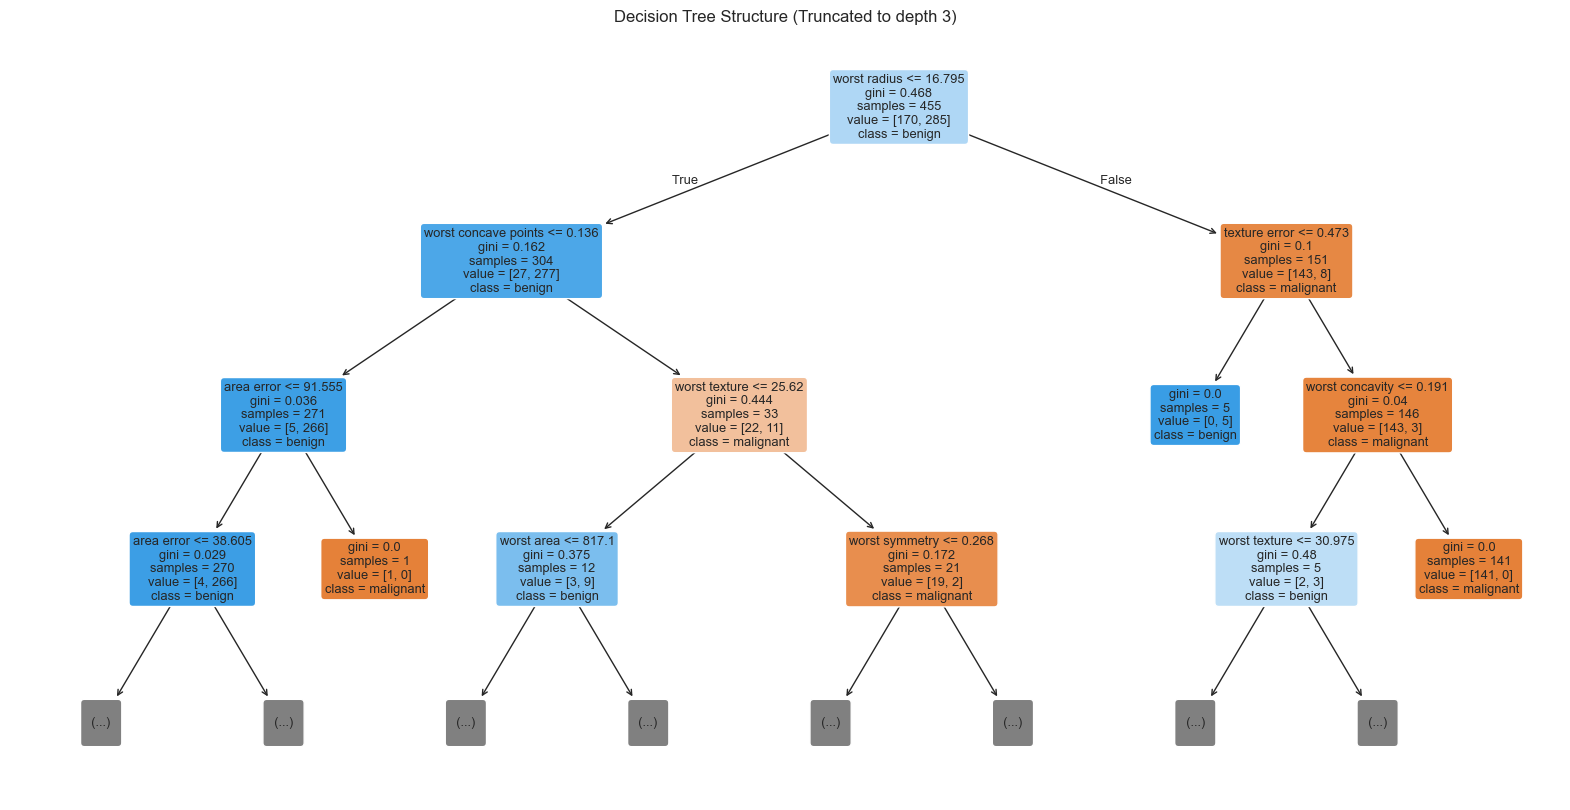

In [23]:
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, 
          feature_names=cancer_data.feature_names,  
          class_names=cancer_data.target_names,
          filled=True, 
          rounded=True, 
          max_depth=3) # Limiting depth for better visibility
plt.title("Decision Tree Structure (Truncated to depth 3)")
plt.show()

In [25]:
# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}


classifier_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

classifier_gs.fit(X_train_c, y_train_c)

best_dt = classifier_gs.best_estimator_
print(accuracy_score(y_test_c, best_dt.predict(X_test_c)))

0.9210526315789473


In [26]:
print(best_dt.feature_importances_)

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.05425521
 0.         0.01245068 0.00182376 0.         0.         0.
 0.         0.         0.71893974 0.04328622 0.         0.00870793
 0.01306189 0.         0.01681942 0.11959747 0.01105768 0.        ]


                Feature  Importance
           worst radius    0.718940
   worst concave points    0.119597
          texture error    0.054255
          worst texture    0.043286
        worst concavity    0.016819
       worst smoothness    0.013062
             area error    0.012451
         worst symmetry    0.011058
             worst area    0.008708
       smoothness error    0.001824
         mean perimeter    0.000000
              mean area    0.000000
            mean radius    0.000000
           mean texture    0.000000
        perimeter error    0.000000
           radius error    0.000000
          mean symmetry    0.000000
 mean fractal dimension    0.000000
    mean concave points    0.000000
         mean concavity    0.000000
        mean smoothness    0.000000
       mean compactness    0.000000
         symmetry error    0.000000
fractal dimension error    0.000000
        concavity error    0.000000
   concave points error    0.000000
      compactness error    0

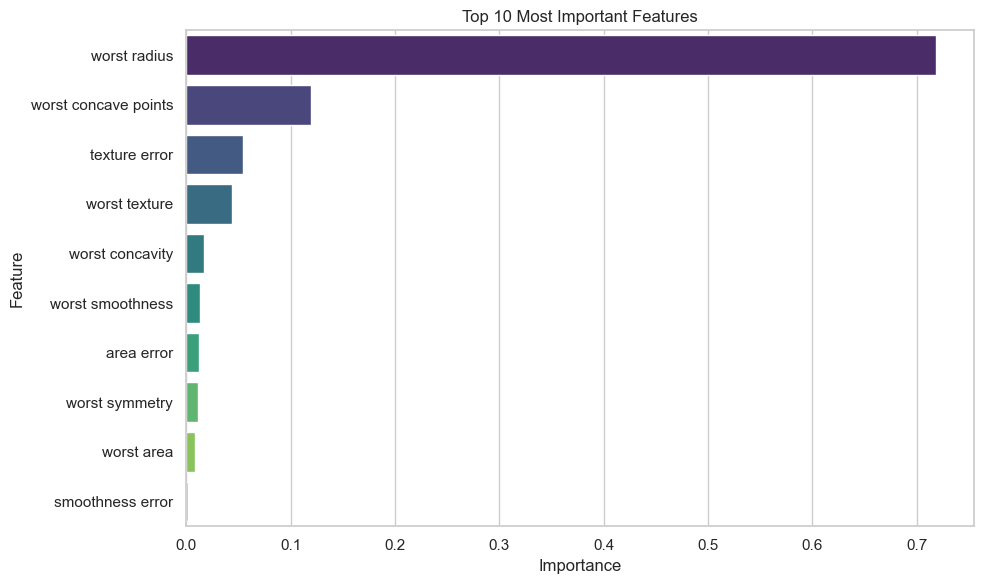

In [28]:
# Get feature importances from the best model
importances = best_dt.feature_importances_

# Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'Feature': cancer_data.feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp_df.to_string(index=False))

# Plot top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

## Random Forest and Boosting

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn modules
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# XGBoost
import xgboost as xgb

# Set plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Load dataset
wine_data = load_wine()
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = wine_data.target

print(f"Dataset shape: {X.shape}")
print(f"Classes: {wine_data.target_names}")
print(f"\nFeature names:")
for i, name in enumerate(wine_data.feature_names):
    print(f"  {i+1}. {name}")

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Dataset shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']

Feature names:
  1. alcohol
  2. malic_acid
  3. ash
  4. alcalinity_of_ash
  5. magnesium
  6. total_phenols
  7. flavanoids
  8. nonflavanoid_phenols
  9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline



Training samples: 142
Testing samples: 36


In [32]:
dt_classifier_2 = DecisionTreeClassifier(random_state=42)

dt_classifier_2.fit(X_train, y_train)
y_c2_predict = dt_classifier_2.predict(X_test)

print(accuracy_score(y_test, y_c2_predict))
print(mean_squared_error(y_test, y_c2_predict))

rf_classifier_1 = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier_1.fit(X_train, y_train)
y_c1_predict = rf_classifier_1.predict(X_test)

print(accuracy_score(y_test, y_c1_predict))
print(mean_squared_error(y_test, y_c1_predict))

0.9444444444444444
0.05555555555555555
1.0
0.0


In [33]:
# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_gs = GridSearchCV(RandomForestClassifier(random_state=42), 
                     param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=1, verbose=1)

rf_gs.fit(X_train, y_train)

best_rf = rf_gs.best_estimator_
print(accuracy_score(y_test, best_rf.predict(X_test)))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
1.0


In [4]:
adaboost_clsfr = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost_clsfr.fit(X_train, y_train)

y_adaboost_predict = adaboost_clsfr.predict(X_test)
adaboost_acc = accuracy_score(y_test, y_adaboost_predict)

gradboost_clsfr = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gradboost_clsfr.fit(X_train, y_train)

y_gradboost_predict = gradboost_clsfr.predict(X_test)
gradboost_acc = accuracy_score(y_test, y_gradboost_predict)

xgboost_clsfr = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgboost_clsfr.fit(X_train, y_train)

y_xgboost_predict = xgboost_clsfr.predict(X_test)
xgboost_acc = accuracy_score(y_test, y_xgboost_predict)

print(f"{adaboost_acc:.4f}")
print(f"{gradboost_acc:.4f}")
print(f"{xgboost_acc:.4f}")

0.9167
0.9444
1.0000


In [5]:
all_results = pd.DataFrame({
    'Model': ['AdaBoost', 'GradBoost', 'XGBoost'],
    'Accuracy': [adaboost_acc, gradboost_acc, xgboost_acc]
}).sort_values(by='Accuracy', ascending=False)

print(all_results.to_string(index=False))

    Model  Accuracy
  XGBoost  1.000000
GradBoost  0.944444
 AdaBoost  0.916667


In [6]:
feature_importance_df = pd.DataFrame({
    'Features': wine_data.feature_names,
    'AdaBoost': adaboost_clsfr.feature_importances_,
    'GradBoost': gradboost_clsfr.feature_importances_,
    'XGBoost': xgboost_clsfr.feature_importances_
})

print(feature_importance_df.to_string(index=False))

                    Features  AdaBoost  GradBoost  XGBoost
                     alcohol  0.028763   0.000756 0.014740
                  malic_acid  0.010338   0.031838 0.046193
                         ash  0.027685   0.026009 0.029721
           alcalinity_of_ash  0.000000   0.005484 0.006308
                   magnesium  0.000000   0.018709 0.091257
               total_phenols  0.000000   0.000920 0.021198
                  flavanoids  0.478352   0.291403 0.256339
        nonflavanoid_phenols  0.000000   0.000120 0.006983
             proanthocyanins  0.000000   0.000573 0.022085
             color_intensity  0.363816   0.311457 0.220617
                         hue  0.028011   0.057246 0.049014
od280/od315_of_diluted_wines  0.011373   0.011608 0.033515
                     proline  0.051661   0.243876 0.202031


In [8]:
feature_importance_df= feature_importance_df.sort_values('AdaBoost', ascending=False)

print(feature_importance_df.to_string(index=False))

                    Features  AdaBoost  GradBoost  XGBoost
                  flavanoids  0.478352   0.291403 0.256339
             color_intensity  0.363816   0.311457 0.220617
                     proline  0.051661   0.243876 0.202031
                     alcohol  0.028763   0.000756 0.014740
                         hue  0.028011   0.057246 0.049014
                         ash  0.027685   0.026009 0.029721
od280/od315_of_diluted_wines  0.011373   0.011608 0.033515
                  malic_acid  0.010338   0.031838 0.046193
           alcalinity_of_ash  0.000000   0.005484 0.006308
                   magnesium  0.000000   0.018709 0.091257
             proanthocyanins  0.000000   0.000573 0.022085
               total_phenols  0.000000   0.000920 0.021198
        nonflavanoid_phenols  0.000000   0.000120 0.006983


## Naive Bayes 
### Gaussian Bayes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.datasets import load_iris, load_breast_cancer, make_classification
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, f1_score,
    roc_curve, auc, ConfusionMatrixDisplay, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
# Multinomial NB for text
docs = [
    'python programming machine learning',
    'python code development software',
    'machine learning deep neural networks',
    'data science statistics analysis',
    'web development javascript html',
    'web design frontend interface',
]

labels = [0, 0, 1, 1, 2, 2]
label_names = ['Python', 'ML/AI', 'Web']

vec = CountVectorizer(lowercase=True, stop_words='english')
X_text = vec.fit_transform(docs)

In [4]:
X_text.get_shape()

(6, 20)

In [5]:
mnb = MultinomialNB(alpha=1.0).fit(X_text, labels)

In [7]:
feature_names = np.array(vec.get_feature_names_out())
feature_names

array(['analysis', 'code', 'data', 'deep', 'design', 'development',
       'frontend', 'html', 'interface', 'javascript', 'learning',
       'machine', 'networks', 'neural', 'programming', 'python',
       'science', 'software', 'statistics', 'web'], dtype=object)

In [19]:
top_idx = np.argsort(mnb.feature_log_prob_[0])[-6:]

In [26]:
mnb.feature_log_prob_[0][top_idx]

array([-2.63905733, -2.63905733, -2.63905733, -2.63905733, -2.63905733,
       -2.23359222])

In [21]:
top_features = feature_names[top_idx]
top_features

array(['development', 'code', 'learning', 'programming', 'software',
       'python'], dtype=object)

In [27]:
# Gaussian NB on Iris
iris = load_iris()
#print("iris_data",iris)
# X_iris = iris.data[:, :2] # two eatures are taken so that visualisation of decision boundary is possible
# #print("X_iris",iris.data)
# y_iris = iris.target
# sc = StandardScaler()
# X_iris_s = sc.fit_transform(X_iris)

GAUSSIAN NB - IRIS DATASET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



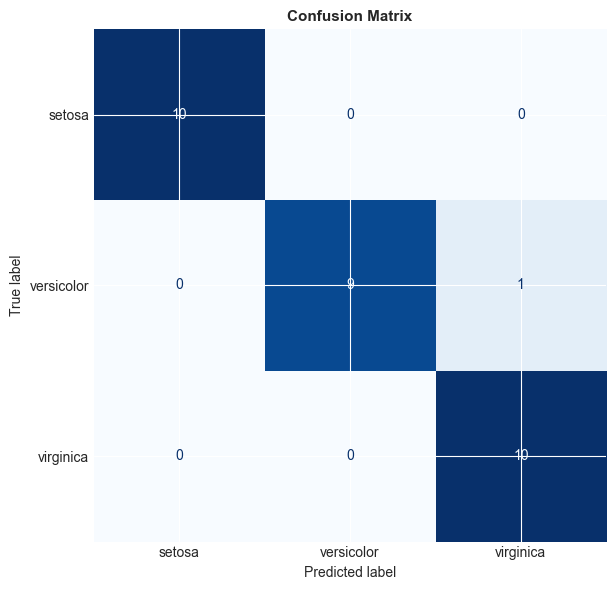

In [28]:
# Full evaluation on Iris
X_tr, X_te, y_tr, y_te = train_test_split(iris.data, iris.target, test_size=0.2,
                                            random_state=42, stratify=iris.target)
sc_iris = StandardScaler()
X_tr_s = sc_iris.fit_transform(X_tr)
X_te_s  = sc_iris.transform(X_te)
gnb_full = GaussianNB().fit(X_tr_s, y_tr)
y_pred_gnb = gnb_full.predict(X_te_s)
print('GAUSSIAN NB - IRIS DATASET')
print('='*60)
print(classification_report(y_te, y_pred_gnb, target_names=iris.target_names))
cm = confusion_matrix(y_te, y_pred_gnb)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()